# GPU-Accelerated Drill-Path Routing with cuOpt

## Goal

A robot must visit every drilling operation on an assembly jig and return to `HOME`.
We want the shortest travel path, while preserving an important process rule:

> The pilot operation at `D-01` must happen before the final ream at `D-01`.

This is a **TSP-style routing problem**: one robot, one route, and every operation must
be completed once. We will build it in two passes:

1. Solve the shortest-distance baseline.
2. Add a process-phase rule that guarantees pilot-before-ream.

**What you will learn**

- Distinguish physical **locations** from work **orders**.
- Build distance and travel-time matrices from factory coordinates.
- Create and solve a one-robot cuOpt routing model.
- Read, validate, and visualize the route.
- Explain what changes when a process rule is added.

The example uses synthetic, customer-generic data from `data/drill_points.csv` and
`data/robot_profiles.csv`.

## The Three Things cuOpt Needs Us To Keep Separate

Before writing code, separate the nouns in the problem:

| Model object | Factory meaning | This notebook |
| --- | --- | --- |
| **Location** | A physical coordinate the robot can move to | `HOME` plus six drill coordinates |
| **Order** | An operation that must be performed | Seven operations |
| **Vehicle** | The resource that follows the route | Robot `R-1` |

Why are there more orders than drill locations? `D-01 Pilot` and `D-01 Final Ream`
happen at the same `(x, y)` coordinate. cuOpt's `set_order_locations()` mapping lets
both operations point to one physical location without expanding the travel matrix.

**Teaching checkpoint:** If two operations share a coordinate, should they become one
order? No. They are distinct pieces of work even though the travel between them is zero.

## Setup

The controls below are the safe places to change the example.

- `ROBOT_ID` chooses the baseline robot.
- `SOLVE_TIME_LIMIT_SEC` controls solver runtime.
- `PHASE_SPLIT_MS` is a **workshop assumption**, not customer process data. It creates
  an early pilot phase and a later ream phase. Replace it with validated process timing
  before using this pattern in production.

In [1]:
from pathlib import Path

import cudf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from cuopt import routing
import cuopt

# Editable workshop controls
ROBOT_ID = "R-1"
SOLVE_TIME_LIMIT_SEC = 2.0
PHASE_SPLIT_MS = 1_000  # Workshop phase boundary for this teaching example

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
DRILL_POINTS_PATH = DATA_DIR / "drill_points.csv"
ROBOT_PROFILES_PATH = DATA_DIR / "robot_profiles.csv"

print(f"cuOpt version: {cuopt.__version__}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Selected robot: {ROBOT_ID}")

cuOpt version: 26.06.00
Project root: /home/rhaber/projects/workshop_cuopt/cuopt_factory_optimization_workshop
Selected robot: R-1


## Step 1: Load and Check the Inputs

We validate the small input tables before building a model. A routing solver can return
a mathematically valid answer to the wrong data, so these checks belong in the workflow.

The source `point_id` identifies a row/operation. Later, we derive a separate
`location_id` from unique coordinates.

In [2]:
if not DRILL_POINTS_PATH.exists() or not ROBOT_PROFILES_PATH.exists():
    raise FileNotFoundError(
        "Run this notebook from the factory workshop project root so data/ is available."
    )

drill_points = pd.read_csv(DRILL_POINTS_PATH)
robot_profiles = pd.read_csv(ROBOT_PROFILES_PATH)

selected_robot_rows = robot_profiles.loc[robot_profiles["robot_id"] == ROBOT_ID]
selected_robot = selected_robot_rows.iloc[0] if len(selected_robot_rows) == 1 else None

home_rows = drill_points.loc[drill_points["operation"] == "home"]
pilot_rows = drill_points.loc[drill_points["operation"] == "pilot"]
ream_rows = drill_points.loc[drill_points["operation"] == "ream"]

input_checks = pd.DataFrame(
    [
        ("Drill point IDs are unique", drill_points["point_id"].is_unique),
        ("Exactly one HOME row exists", len(home_rows) == 1),
        ("Exactly one pilot operation exists", len(pilot_rows) == 1),
        ("Exactly one final ream exists", len(ream_rows) == 1),
        ("Selected robot exists exactly once", len(selected_robot_rows) == 1),
        (
            "Coordinates are complete",
            not drill_points[["x_mm", "y_mm"]].isna().any().any(),
        ),
        (
            "Pilot and final ream share a coordinate",
            len(pilot_rows) == 1
            and len(ream_rows) == 1
            and tuple(pilot_rows[["x_mm", "y_mm"]].iloc[0])
            == tuple(ream_rows[["x_mm", "y_mm"]].iloc[0]),
        ),
    ],
    columns=["check", "passed"],
)

display(input_checks)
if not input_checks["passed"].all():
    raise ValueError("Fix the failed input checks before building the routing model.")

display(drill_points)
display(robot_profiles)

,check,passed
0,Drill point IDs are unique,True
1,Exactly one HOME row exists,True
2,Exactly one pilot operation exists,True
3,Exactly one final ream exists,True
4,Selected robot exists exactly once,True
5,Coordinates are complete,True
6,Pilot and final ream share a coordinate,True


,point_id,label,x_mm,y_mm,operation,zone
0,0,HOME,0,0,home,home
1,1,D-01 Pilot,120,340,pilot,A
2,2,D-02 Drill,260,340,drill,A
3,3,D-03 Drill,400,340,drill,A
4,4,D-04 Drill,120,180,drill,B
5,5,D-05 Drill,260,180,drill,B
6,6,D-06 Drill,400,180,drill,B
7,7,D-01 Final Ream,120,340,ream,A


,robot_id,start_location,end_location,speed_mm_per_sec,available_from_sec,max_time_sec
0,R-1,0,0,1500,0,900
1,R-2,0,0,1400,0,900


## Step 2: Map Operations to Physical Locations

The cost matrix describes travel **between coordinates**, not between labels. We therefore:

1. Deduplicate `(x_mm, y_mm)` pairs into physical locations.
2. Remove `HOME` from the work-order list.
3. Map every work order to a physical `location_id`.

This is the most important data-modeling step in the notebook.

In [3]:
physical_locations = (
    drill_points[["x_mm", "y_mm"]]
    .drop_duplicates()
    .reset_index(drop=True)
    .reset_index(names="location_id")
)

drill_points = drill_points.merge(
    physical_locations,
    on=["x_mm", "y_mm"],
    how="left",
    validate="many_to_one",
)

orders = (
    drill_points.loc[drill_points["operation"] != "home"]
    .reset_index(drop=True)
    .copy()
)
orders.insert(0, "order_id", np.arange(len(orders), dtype=np.int32))

point_to_location = drill_points.set_index("point_id")["location_id"].to_dict()
start_location_id = int(point_to_location[int(selected_robot["start_location"])])
end_location_id = int(point_to_location[int(selected_robot["end_location"])])

mapping_summary = pd.DataFrame(
    {
        "model_count": [len(physical_locations), len(orders), 1],
    },
    index=["physical locations", "work orders", "robots in baseline"],
)

display(mapping_summary)
display(
    orders[
        [
            "order_id",
            "point_id",
            "label",
            "operation",
            "zone",
            "location_id",
            "x_mm",
            "y_mm",
        ]
    ]
)

,model_count
physical locations,7
work orders,7
robots in baseline,1


,order_id,point_id,label,operation,zone,location_id,x_mm,y_mm
0,0,1,D-01 Pilot,pilot,A,1,120,340
1,1,2,D-02 Drill,drill,A,2,260,340
2,2,3,D-03 Drill,drill,A,3,400,340
3,3,4,D-04 Drill,drill,B,4,120,180
4,4,5,D-05 Drill,drill,B,5,260,180
5,5,6,D-06 Drill,drill,B,6,400,180
6,6,7,D-01 Final Ream,ream,A,1,120,340


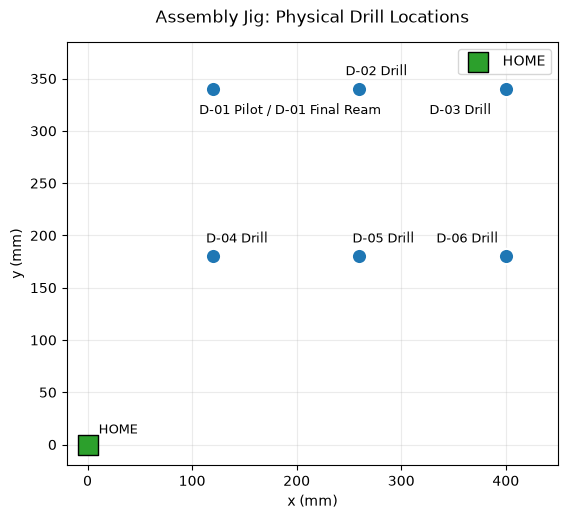

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))

home_location_id = int(home_rows.merge(
    physical_locations, on=["x_mm", "y_mm"], how="left"
)["location_id"].iloc[0])

ax.scatter(
    physical_locations["x_mm"],
    physical_locations["y_mm"],
    s=120,
    color="#1f77b4",
    edgecolor="white",
    linewidth=1.5,
    zorder=3,
)
home = physical_locations.loc[physical_locations["location_id"] == home_location_id].iloc[0]
ax.scatter(
    home["x_mm"],
    home["y_mm"],
    s=190,
    marker="s",
    color="#2ca02c",
    edgecolor="black",
    label="HOME",
    zorder=4,
)

labels_by_location = (
    drill_points.groupby("location_id", sort=True)["label"]
    .apply(lambda values: " / ".join(values))
    .to_dict()
)
input_label_offsets = {
    0: (8, 8),
    1: (-10, -18),
    2: (-10, 10),
    3: (-55, -18),
    4: (-5, 10),
    5: (-5, 10),
    6: (-50, 10),
}
for location in physical_locations.itertuples():
    ax.annotate(
        labels_by_location[location.location_id],
        (location.x_mm, location.y_mm),
        xytext=input_label_offsets.get(location.location_id, (7, 7)),
        textcoords="offset points",
        fontsize=9,
    )

ax.set_title("Assembly Jig: Physical Drill Locations", pad=14)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_xlim(-20, 450)
ax.set_ylim(-20, 385)
ax.grid(alpha=0.25)
ax.set_aspect("equal", adjustable="box")
ax.legend()
plt.show()

## Step 3: Build the Travel Matrices

The baseline objective is Euclidean travel distance in millimeters:

\[
d(i,j)=\sqrt{(x_i-x_j)^2+(y_i-y_j)^2}
\]

We also derive travel time in milliseconds using the selected robot's speed. Distance is
the objective; travel time is used later to enforce process-phase timing.

**Known limitation:** the input does not contain drilling, inspection, or reaming service
durations. We leave them at zero instead of inventing them. Add validated cycle times when
they become available.

In [5]:
coordinates_mm = physical_locations[["x_mm", "y_mm"]].to_numpy(dtype=np.float32)
coordinate_deltas = coordinates_mm[:, None, :] - coordinates_mm[None, :, :]
distance_matrix_mm = np.sqrt((coordinate_deltas ** 2).sum(axis=2)).astype(np.float32)

robot_speed_mm_per_sec = float(selected_robot["speed_mm_per_sec"])
travel_time_matrix_ms = (
    distance_matrix_mm / robot_speed_mm_per_sec * 1_000.0
).astype(np.float32)

matrix_labels = [f"L{location_id}" for location_id in physical_locations["location_id"]]
distance_preview = pd.DataFrame(
    distance_matrix_mm,
    index=matrix_labels,
    columns=matrix_labels,
).round(1)

print(f"Robot speed: {robot_speed_mm_per_sec:,.0f} mm/sec")
print("Distance matrix (mm):")
display(distance_preview)

Robot speed: 1,500 mm/sec
Distance matrix (mm):


,L0,L1,L2,L3,L4,L5,L6
L0,0.000000,360.600006,428.000000,525.000000,216.300003,316.200012,438.600006
L1,360.600006,0.000000,140.000000,280.000000,160.000000,212.600006,322.500000
L2,428.000000,140.000000,0.000000,140.000000,212.600006,160.000000,212.600006
L3,525.000000,280.000000,140.000000,0.000000,322.500000,212.600006,160.000000
L4,216.300003,160.000000,212.600006,322.500000,0.000000,140.000000,280.000000
L5,316.200012,212.600006,160.000000,212.600006,140.000000,0.000000,140.000000
L6,438.600006,322.500000,212.600006,160.000000,280.000000,140.000000,0.000000


## Step 4: Build the Baseline TSP-Style Model

`DataModel(n_locations, n_fleet, n_orders)` makes the three model counts explicit.

We then add:

1. The distance matrix—the cost we minimize.
2. The order-to-location mapping.
3. The robot's start and return locations.

There is no capacity dimension because this robot is not carrying deliveries. There are
no time windows yet because the baseline asks only for the shortest route.

In [6]:
baseline_model = routing.DataModel(
    len(physical_locations),
    1,
    len(orders),
)
baseline_model.add_cost_matrix(cudf.DataFrame(distance_matrix_mm))
baseline_model.set_order_locations(
    cudf.Series(orders["location_id"], dtype=np.int32)
)
baseline_model.set_vehicle_locations(
    cudf.Series([start_location_id], dtype=np.int32),
    cudf.Series([end_location_id], dtype=np.int32),
)

solver_settings = routing.SolverSettings()
solver_settings.set_time_limit(SOLVE_TIME_LIMIT_SEC)

print("Baseline model built.")

Baseline model built.


## Step 5: Solve and Read the Route

cuOpt returns both an order identifier (`route`) and a physical `location`. Depot rows use
the home location; delivery rows use the order IDs we created above.

The helper below translates that solver-oriented output into a workshop table with labels,
leg distances, and cumulative distance.

In [7]:
baseline_solution = routing.Solve(baseline_model, solver_settings)

if baseline_solution.get_status() != 0:
    raise RuntimeError(
        f"Baseline solve failed with status {baseline_solution.get_status()}"
    )

print("Baseline solution found.")
print(f"Total travel distance: {baseline_solution.get_total_objective():,.1f} mm")

Baseline solution found.
Total travel distance: 1,272.6 mm


In [8]:
def solution_to_route_table(solution):
    raw_route = solution.get_route().to_pandas().reset_index(drop=True)
    order_lookup = orders.set_index("order_id").to_dict(orient="index")
    records = []

    for sequence, row in raw_route.iterrows():
        stop_type = str(row["type"])
        location_id = int(row["location"])

        if stop_type == "Depot":
            order_id = pd.NA
            source_point_id = int(home_rows["point_id"].iloc[0])
            label = "HOME"
            operation = "home"
        else:
            order_id = int(row["route"])
            order = order_lookup[order_id]
            source_point_id = int(order["point_id"])
            label = order["label"]
            operation = order["operation"]

        location = physical_locations.loc[
            physical_locations["location_id"] == location_id
        ].iloc[0]

        records.append(
            {
                "sequence": sequence,
                "stop_type": stop_type,
                "order_id": order_id,
                "source_point_id": source_point_id,
                "label": label,
                "operation": operation,
                "location_id": location_id,
                "x_mm": float(location["x_mm"]),
                "y_mm": float(location["y_mm"]),
                "arrival_ms": float(row["arrival_stamp"]),
            }
        )

    route_table = pd.DataFrame(records)
    leg_distances = [0.0]
    for previous_location, current_location in zip(
        route_table["location_id"].iloc[:-1],
        route_table["location_id"].iloc[1:],
    ):
        leg_distances.append(
            float(distance_matrix_mm[int(previous_location), int(current_location)])
        )

    route_table["leg_distance_mm"] = leg_distances
    route_table["leg_move_time_ms"] = (
        route_table["leg_distance_mm"] / robot_speed_mm_per_sec * 1_000.0
    )
    route_table["cumulative_distance_mm"] = route_table["leg_distance_mm"].cumsum()
    return route_table


baseline_route = solution_to_route_table(baseline_solution)
baseline_path = " → ".join(baseline_route["label"])

print(baseline_path)
display(
    baseline_route[
        [
            "sequence",
            "label",
            "operation",
            "location_id",
            "leg_distance_mm",
            "cumulative_distance_mm",
        ]
    ].round(1)
)

HOME → D-04 Drill → D-01 Pilot → D-01 Final Ream → D-02 Drill → D-03 Drill → D-06 Drill → D-05 Drill → HOME


,sequence,label,operation,location_id,leg_distance_mm,cumulative_distance_mm
0,0,HOME,home,0,0.0,0.0
1,1,D-04 Drill,drill,4,216.3,216.3
2,2,D-01 Pilot,pilot,1,160.0,376.3
3,3,D-01 Final Ream,ream,1,0.0,376.3
4,4,D-02 Drill,drill,2,140.0,516.3
5,5,D-03 Drill,drill,3,140.0,656.3
6,6,D-06 Drill,drill,6,160.0,816.3
7,7,D-05 Drill,drill,5,140.0,956.3
8,8,HOME,home,0,316.2,1272.6


### Baseline Validation

A plausible-looking plot is not enough. We check that:

- every operation appears exactly once;
- the route starts and ends at `HOME`;
- the reconstructed leg distances match cuOpt's objective.

We also inspect pilot versus ream order. The baseline may happen to place pilot first, but
without a process constraint that behavior is not guaranteed by the model.

In [9]:
baseline_delivery_ids = (
    baseline_route.loc[baseline_route["stop_type"] == "Delivery", "order_id"]
    .astype(int)
    .tolist()
)
baseline_distance_mm = float(baseline_solution.get_total_objective())
reconstructed_distance_mm = float(baseline_route["leg_distance_mm"].sum())

pilot_order_id = int(orders.loc[orders["operation"] == "pilot", "order_id"].iloc[0])
ream_order_id = int(orders.loc[orders["operation"] == "ream", "order_id"].iloc[0])
baseline_pilot_step = baseline_delivery_ids.index(pilot_order_id) + 1
baseline_ream_step = baseline_delivery_ids.index(ream_order_id) + 1

baseline_checks = pd.DataFrame(
    [
        ("Every order appears exactly once", sorted(baseline_delivery_ids) == list(range(len(orders)))),
        ("Route starts at HOME", baseline_route.iloc[0]["label"] == "HOME"),
        ("Route returns to HOME", baseline_route.iloc[-1]["label"] == "HOME"),
        (
            "Leg distances reconcile to cuOpt objective",
            np.isclose(reconstructed_distance_mm, baseline_distance_mm, atol=1e-3),
        ),
    ],
    columns=["check", "passed"],
)
display(baseline_checks)

if not baseline_checks["passed"].all():
    raise AssertionError("A baseline route validation check failed.")

print(f"Pilot route step: {baseline_pilot_step}")
print(f"Final ream route step: {baseline_ream_step}")
print(
    "Baseline observation: "
    + ("pilot happened first, but is not guaranteed." if baseline_pilot_step < baseline_ream_step
       else "ream happened first, which exposes the missing process rule.")
)

,check,passed
0,Every order appears exactly once,True
1,Route starts at HOME,True
2,Route returns to HOME,True
3,Leg distances reconcile to cuOpt objective,True


Pilot route step: 2
Final ream route step: 3
Baseline observation: pilot happened first, but is not guaranteed.


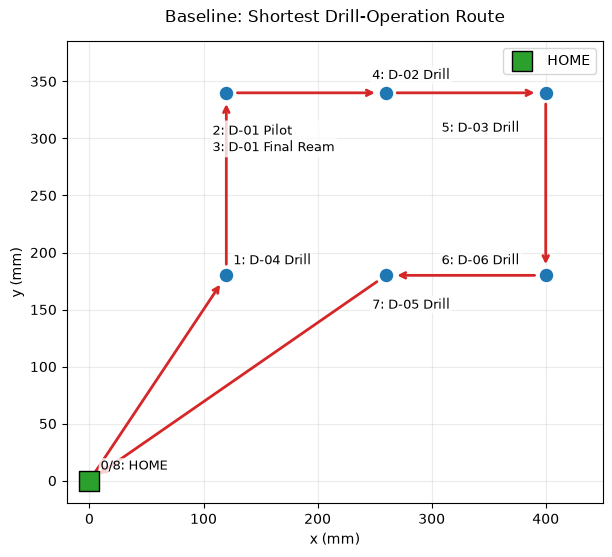

In [10]:
def plot_route(route_table, title):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.scatter(
        physical_locations["x_mm"],
        physical_locations["y_mm"],
        s=125,
        color="#1f77b4",
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
    )
    ax.scatter(
        home["x_mm"],
        home["y_mm"],
        s=200,
        marker="s",
        color="#2ca02c",
        edgecolor="black",
        label="HOME",
        zorder=4,
    )

    for previous, current in zip(
        route_table.itertuples(index=False),
        route_table.iloc[1:].itertuples(index=False),
    ):
        if previous.location_id == current.location_id:
            continue
        ax.annotate(
            "",
            xy=(current.x_mm, current.y_mm),
            xytext=(previous.x_mm, previous.y_mm),
            arrowprops=dict(
                arrowstyle="->",
                color="#d62728",
                lw=2,
                shrinkA=8,
                shrinkB=8,
            ),
            zorder=2,
        )

    stop_notes = (
        route_table.groupby("location_id", sort=False)
        .apply(
            lambda group: "\n".join(
                f"{int(row.sequence)}: {row.label}" for row in group.itertuples()
            ),
            include_groups=False,
        )
        .to_dict()
    )
    home_steps = route_table.loc[
        route_table["location_id"] == home_location_id, "sequence"
    ].astype(int).tolist()
    stop_notes[home_location_id] = (
        f"{home_steps[0]}/{home_steps[-1]}: HOME"
    )
    route_label_offsets = {
        0: (8, 8),
        1: (-10, -42),
        2: (-10, 10),
        3: (-75, -28),
        4: (5, 8),
        5: (-10, -24),
        6: (-75, 8),
    }
    for location in physical_locations.itertuples():
        ax.annotate(
            stop_notes.get(location.location_id, ""),
            (location.x_mm, location.y_mm),
            xytext=route_label_offsets.get(location.location_id, (8, 8)),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.8,
            ),
        )

    ax.set_title(title, pad=14)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_xlim(-20, 450)
    ax.set_ylim(-20, 385)
    ax.grid(alpha=0.25)
    ax.set_aspect("equal", adjustable="box")
    ax.legend()
    plt.show()


plot_route(baseline_route, "Baseline: Shortest Drill-Operation Route")

## Step 6: Add the Pilot-Before-Ream Process Rule

A direct arbitrary order-precedence solve is not supported by the installed cuOpt 26.06
routing engine. For this workshop, we express the real intent as **process phases**:

- the pilot operation must occur before `PHASE_SPLIT_MS`;
- the final ream cannot begin until `PHASE_SPLIT_MS`;
- all other drilling operations remain available across the robot's work horizon.

With one robot, these non-overlapping time windows guarantee pilot-before-ream.

This is intentionally an editable teaching assumption. A production model needs confirmed
timing, including drilling/reaming service durations, inspection delay, tool changes, and
any safety or geometry constraints.

**Teaching checkpoint:** What changed—data, constraint, objective, or problem class?

We added timing data and a routing constraint. The distance objective and routing problem
family stayed the same.

In [11]:
robot_horizon_ms = int(float(selected_robot["max_time_sec"]) * 1_000)
if not 0 < PHASE_SPLIT_MS < robot_horizon_ms:
    raise ValueError("PHASE_SPLIT_MS must fall inside the robot's available horizon.")

earliest_ms = np.zeros(len(orders), dtype=np.int32)
latest_ms = np.full(len(orders), robot_horizon_ms, dtype=np.int32)
latest_ms[pilot_order_id] = PHASE_SPLIT_MS - 1
earliest_ms[ream_order_id] = PHASE_SPLIT_MS

process_windows = orders[
    ["order_id", "label", "operation", "location_id"]
].copy()
process_windows["earliest_ms"] = earliest_ms
process_windows["latest_ms"] = latest_ms
display(process_windows)

,order_id,label,operation,location_id,earliest_ms,latest_ms
0,0,D-01 Pilot,pilot,1,0,999
1,1,D-02 Drill,drill,2,0,900000
2,2,D-03 Drill,drill,3,0,900000
3,3,D-04 Drill,drill,4,0,900000
4,4,D-05 Drill,drill,5,0,900000
5,5,D-06 Drill,drill,6,0,900000
6,6,D-01 Final Ream,ream,1,1000,900000


In [12]:
phase_model = routing.DataModel(
    len(physical_locations),
    1,
    len(orders),
)
phase_model.add_cost_matrix(cudf.DataFrame(distance_matrix_mm))
phase_model.add_transit_time_matrix(cudf.DataFrame(travel_time_matrix_ms))
phase_model.set_order_locations(
    cudf.Series(orders["location_id"], dtype=np.int32)
)
phase_model.set_vehicle_locations(
    cudf.Series([start_location_id], dtype=np.int32),
    cudf.Series([end_location_id], dtype=np.int32),
)
phase_model.set_order_time_windows(
    cudf.Series(earliest_ms, dtype=np.int32),
    cudf.Series(latest_ms, dtype=np.int32),
)

# Service durations are unknown in the source data, so we explicitly use zero.
phase_model.set_order_service_times(
    cudf.Series(np.zeros(len(orders), dtype=np.int32))
)

phase_solution = routing.Solve(phase_model, solver_settings)
if phase_solution.get_status() != 0:
    raise RuntimeError(
        f"Process-aware solve failed with status {phase_solution.get_status()}"
    )

phase_route = solution_to_route_table(phase_solution)
phase_path = " → ".join(phase_route["label"])

print(phase_path)
display(
    phase_route[
        [
            "sequence",
            "label",
            "operation",
            "location_id",
            "arrival_ms",
            "leg_distance_mm",
            "cumulative_distance_mm",
        ]
    ].round(1)
)

HOME → D-04 Drill → D-01 Pilot → D-01 Final Ream → D-02 Drill → D-03 Drill → D-06 Drill → D-05 Drill → HOME


,sequence,label,operation,location_id,arrival_ms,leg_distance_mm,cumulative_distance_mm
0,0,HOME,home,0,0.0,0.0,0.0
1,1,D-04 Drill,drill,4,144.2,216.3,216.3
2,2,D-01 Pilot,pilot,1,250.9,160.0,376.3
3,3,D-01 Final Ream,ream,1,1000.0,0.0,376.3
4,4,D-02 Drill,drill,2,1093.3,140.0,516.3
5,5,D-03 Drill,drill,3,1186.7,140.0,656.3
6,6,D-06 Drill,drill,6,1293.3,160.0,816.3
7,7,D-05 Drill,drill,5,1386.7,140.0,956.3
8,8,HOME,home,0,1597.5,316.2,1272.6


## Checks and Comparison

The process-aware route must still visit every operation once and reconcile to the solver
objective. It must also place the pilot before the final ream and satisfy both phase windows.

A constraint does not have to change the chosen path to be valuable. If the unconstrained
route already follows the desired order, the constraint turns an accidental behavior into
a guarantee.

In [13]:
phase_delivery_ids = (
    phase_route.loc[phase_route["stop_type"] == "Delivery", "order_id"]
    .astype(int)
    .tolist()
)
phase_pilot_row = phase_route.loc[phase_route["order_id"] == pilot_order_id].iloc[0]
phase_ream_row = phase_route.loc[phase_route["order_id"] == ream_order_id].iloc[0]
phase_distance_mm = float(phase_solution.get_total_objective())
phase_reconstructed_mm = float(phase_route["leg_distance_mm"].sum())

final_checks = pd.DataFrame(
    [
        ("Every order appears exactly once", sorted(phase_delivery_ids) == list(range(len(orders)))),
        ("Route starts and ends at HOME", phase_route.iloc[0]["label"] == "HOME" and phase_route.iloc[-1]["label"] == "HOME"),
        ("Pilot is before final ream", int(phase_pilot_row["sequence"]) < int(phase_ream_row["sequence"])),
        ("Pilot meets its early-phase window", float(phase_pilot_row["arrival_ms"]) <= PHASE_SPLIT_MS - 1),
        ("Final ream meets its late-phase window", float(phase_ream_row["arrival_ms"]) >= PHASE_SPLIT_MS),
        ("Leg distances reconcile to objective", np.isclose(phase_reconstructed_mm, phase_distance_mm, atol=1e-3)),
    ],
    columns=["check", "passed"],
)
display(final_checks)
if not final_checks["passed"].all():
    raise AssertionError("A process-aware route validation check failed.")

baseline_move_time_ms = baseline_distance_mm / robot_speed_mm_per_sec * 1_000.0
phase_finish_ms = float(phase_route.iloc[-1]["arrival_ms"])
implied_wait_ms = max(0.0, phase_finish_ms - phase_distance_mm / robot_speed_mm_per_sec * 1_000.0)

comparison = pd.DataFrame(
    [
        {
            "model": "Shortest-distance baseline",
            "distance_mm": baseline_distance_mm,
            "geometric_move_time_ms": baseline_move_time_ms,
            "route_finish_ms": np.nan,
            "pilot_before_ream_guaranteed": False,
        },
        {
            "model": "Process-phase constrained",
            "distance_mm": phase_distance_mm,
            "geometric_move_time_ms": phase_distance_mm / robot_speed_mm_per_sec * 1_000.0,
            "route_finish_ms": phase_finish_ms,
            "pilot_before_ream_guaranteed": True,
        },
    ]
)

display(comparison.round(1))
print(f"Process-phase waiting implied by the teaching split: {implied_wait_ms:,.1f} ms")

,check,passed
0,Every order appears exactly once,True
1,Route starts and ends at HOME,True
2,Pilot is before final ream,True
3,Pilot meets its early-phase window,True
4,Final ream meets its late-phase window,True
5,Leg distances reconcile to objective,True


,model,distance_mm,geometric_move_time_ms,route_finish_ms,pilot_before_ream_guaranteed
0,Shortest-distance baseline,1272.6,848.4,NaN,False
1,Process-phase constrained,1272.6,848.4,1597.5,True


Process-phase waiting implied by the teaching split: 749.1 ms


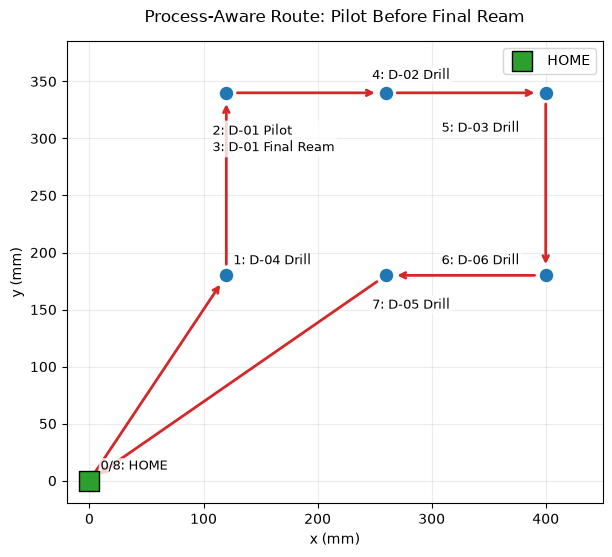

In [14]:
plot_route(phase_route, "Process-Aware Route: Pilot Before Final Ream")

## Takeaways

| Addition | Data | Constraint | Objective | Problem class |
| --- | --- | --- | --- | --- |
| Base drill path | coordinates and robot | visit every order once | minimize distance | TSP-style routing |
| Pilot-before-ream phases | travel time and phase windows | pilot early, ream later | same distance objective | constrained TSP-style routing |

The important modeling insight is not the small route itself. It is the separation between:

- physical coordinates in the cost matrix;
- operations in the order list;
- process rules expressed as routing constraints.

## Next Steps

1. Replace `PHASE_SPLIT_MS` and zero service times with validated process timing.
2. Replace Euclidean distance with collision-aware robot motion time if a path planner is available.
3. Add tool-change, clamp-position, safety-zone, or inspection rules only after their exact
   semantics are confirmed.
4. Add `R-2` as a separate extension. At that point the teaching story moves from one-route
   TSP-style routing toward a multi-robot VRP-style problem.

**Reflection questions**

- Why are `D-01 Pilot` and `D-01 Final Ream` two orders but one location?
- Why did we keep distance as the objective while using time for feasibility?
- If a second robot is added, which new decisions and constraints appear?
- Which missing process measurements must be collected before this becomes production-ready?

Further reading: [NVIDIA cuOpt routing Python API](https://docs.nvidia.com/cuopt/user-guide/26.06/cuopt-python/routing/routing-api.html)